### Classifying Quasar

In this exercise we have measured different magnitudes of galaxies and quasars. Our aim is to correctly label quasars, using different methods of generative classification.

In [2]:
from sklearn import metrics 
import numpy as np
from matplotlib import pyplot as plt
import sklearn.model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
from sklearn.metrics import roc_curve, auc
from scipy.stats import chi2
import scipy
#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize = 10, usetex = True)
from astroML.utils import completeness_contamination
from scipy.stats import loguniform
from sklearn import datasets
from sklearn import manifold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
path = 'solutions/galaxyquasar.csv'
from astropy.table import Table
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import cross_val_predict


In [3]:
data = Table.read(path)
print(data)

   u        g        r        i        z     class      z1         zerr    
-------- -------- -------- -------- -------- ------ ---------- ------------
18.97213 18.53676  18.5828 18.34936 18.29215    QSO  0.5228189 0.0001547483
19.24592 17.47646 16.47817 16.04472 15.68851 GALAXY  0.1228459 2.816076e-05
19.43536 17.70268 16.91565 16.58327 16.39128 GALAXY        0.0          0.0
19.31626 18.18312 17.39591 16.94549 16.65395 GALAXY  0.1474355 9.310701e-06
19.28828 19.11188 18.88937 18.80013 18.49183    QSO   2.011455 0.0006307968
17.60994 15.90911  15.0209 14.54955 14.19971 GALAXY 0.04619161 1.022329e-05
18.50014 17.42286 17.03657 16.76236 16.63258 GALAXY  0.0516851 6.667251e-06
19.53253 19.49823 19.42254 19.07912 18.90426    QSO    1.88844 0.0005242734
19.37014 17.94086   17.154 16.74367 16.42825 GALAXY   0.137445 1.284492e-05
18.94777 16.99748 16.10991 15.71294 15.38205 GALAXY 0.05139576 1.215115e-05
     ...      ...      ...      ...      ...    ...        ...          ...
19.33615 18.

In [4]:
u = data['u']
g = data['g']
r = data['r']
i = data['i']
z = data['z']

In [5]:
ug = np.array(u-g)
gr = np.array(g-r)
ri = np.array(r-i)
iz = np.array(i-z)


In [6]:
classif = np.where(data['class'] == 'GALAXY', 0, 1)
print(classif)

[1 0 0 ... 0 0 0]


Visualizing different colors

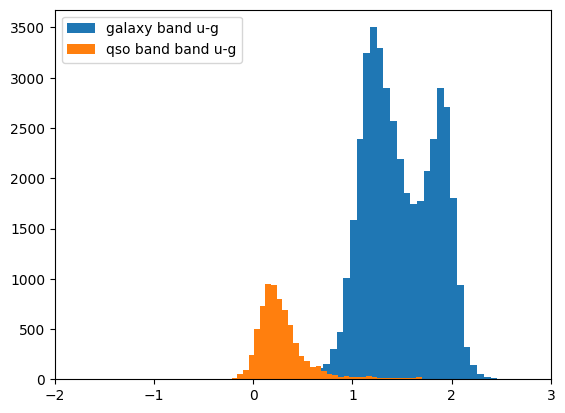

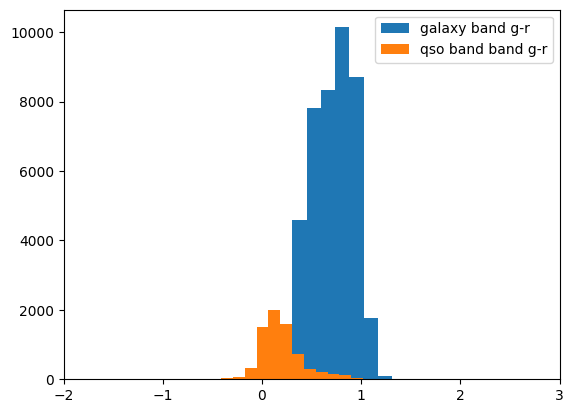

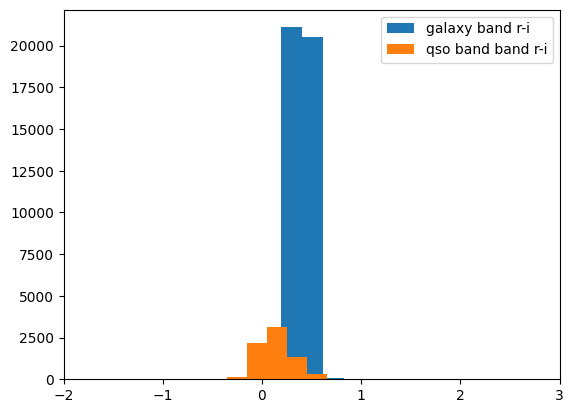

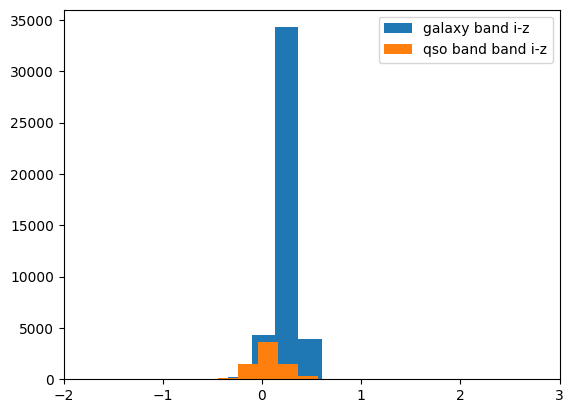

In [7]:
band = [ug, gr, ri, iz]
name = ['u-g', 'g-r', 'r-i', 'i-z']
for i in range(len(band)):
    plt.hist(band[i][classif == 0], bins = 100, label = f'galaxy band {name[i]}')
    plt.hist(band[i][classif ==1], bins = 100, label = f'qso band band {name[i]}')
    plt.legend()
    plt.xlim(-2,3)
    plt.show()

From this brief analysis it seems that the most discriminative feature is the difference of magnitudes u-g

## Naive Bayes
As a first classifer we are using Naive Bayes, assuming that the features have no covariance and that the probability of obtain a specific feature given a class is gaussian. 

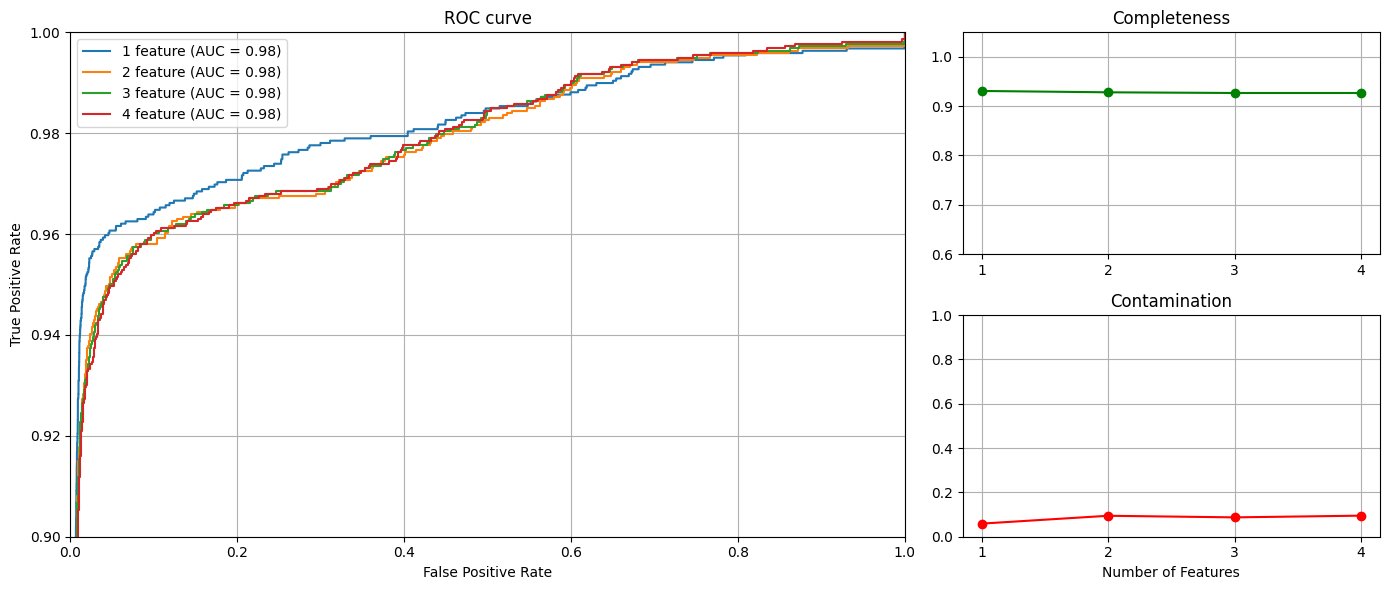

In [8]:
x = np.array([ug, gr, ri, iz]).T
y =classif
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.3, random_state=42
)
clf = GaussianNB()
completeness_list = []
contamination_list = []
roc_curves = []
for i in range(len(band)):
    #fitting the data with an increasing number of feature
    clf.fit(xtrain[:,0:i+1],ytrain)
    
    #predict the probability that the test set considered, given the values of the magnitudes, is a quasar
    y_prob = clf.predict_proba(xtest[:,0:i+1])[:,1]
    
    #compute the false positive rate, true positive rate and the threshold
    fpr, tpr, thresh = roc_curve(ytest, y_prob)  
    y_pred = clf.predict(xtest[:,0:i+1])
    roc_auc = auc(fpr, tpr)
    comp, cont = completeness_contamination(y_pred, ytest)
    completeness_list.append(comp)
    contamination_list.append(cont)
    roc_curves.append((fpr, tpr, roc_auc, i+1))


fig = plt.figure(figsize=(14, 6))
gs = GridSpec(2, 2, width_ratios=[2, 1])

# ROC plot 
ax0 = fig.add_subplot(gs[:, 0])
for fpr, tpr, auc_val, nfeat in roc_curves:
    ax0.plot(fpr, tpr, label=f'{nfeat} feature (AUC = {auc_val:.2f})')
ax0.set_xlim([0, 1])
ax0.set_ylim([0.9, 1])
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.set_title('ROC curve')
ax0.grid(True)
ax0.legend()

#Completeness
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(range(1, len(band)+1), completeness_list, 'o-g')
ax1.set_title('Completeness')
ax1.set_xticks(range(1, len(band)+1))
ax1.set_ylim(0.6, 1.05)
ax1.grid(True)

#Contamination
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(range(1, len(band)+1), contamination_list, 'o-r')
ax2.set_title('Contamination')
ax2.set_xticks(range(1, len(band)+1))
ax2.set_ylim(0, 1)
ax2.set_xlabel('Number of Features')
ax2.grid(True)

plt.tight_layout()
plt.show()


From the ROC Curves we can see that with just one feature, u-g, the classifier can correctly identify most of the Quasars

## Quadratic discriminant analysis
In QDA each class has its mean and covariance and the p(x|y) is a multivariate gaussian.

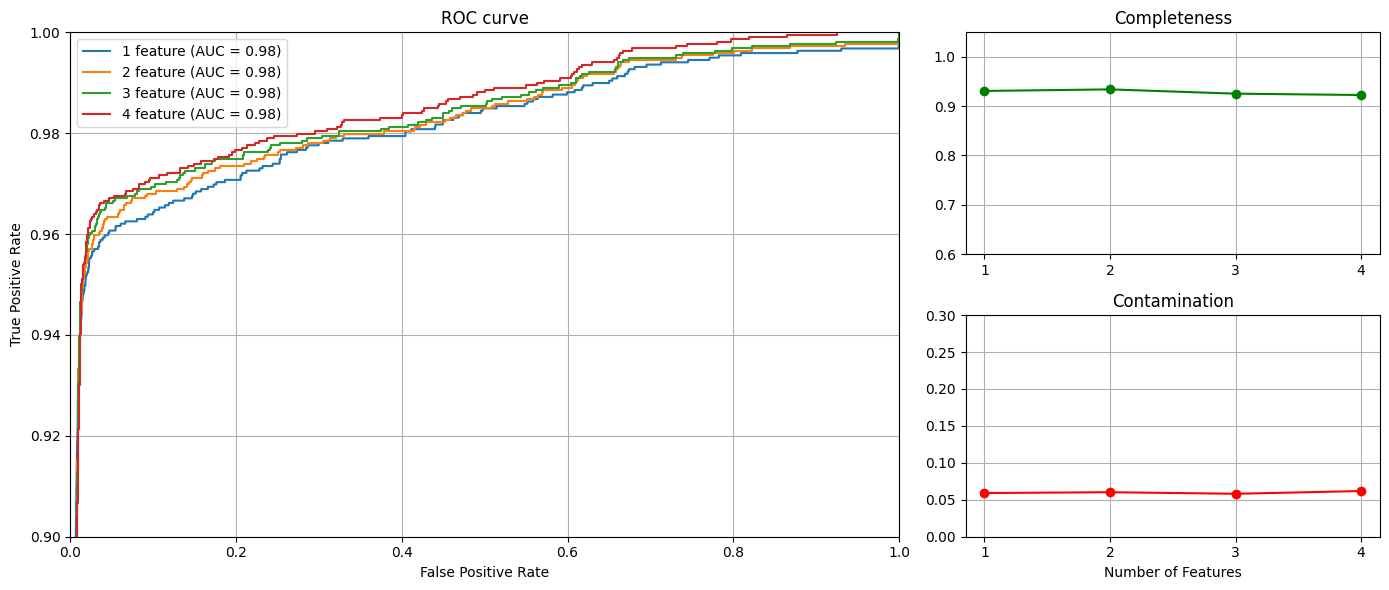

In [9]:
clf_q = QuadraticDiscriminantAnalysis()
completeness_list = []
contamination_list = []
roc_curves = []
for i in range(len(band)):
    #fitting the data with an increasing number of feature
    clf_q.fit(xtrain[:,0:i+1],ytrain)
    #predict the probability that the test set considered, given the values of the magnitudes, is a quasar
    y_prob = clf_q.predict_proba(xtest[:,0:i+1])[:,1]
    #compute the false positive rate, true positive rate and the threshold
    fpr, tpr, thresh = roc_curve(ytest, y_prob)  
    y_pred = clf_q.predict(xtest[:,0:i+1])
    roc_auc = auc(fpr, tpr)
    comp, cont = completeness_contamination(y_pred, ytest)
    completeness_list.append(comp)
    contamination_list.append(cont)
    roc_curves.append((fpr, tpr, roc_auc, i+1))


fig = plt.figure(figsize=(14, 6))
gs = GridSpec(2, 2, width_ratios=[2, 1])

# ROC plot 
ax0 = fig.add_subplot(gs[:, 0])
for fpr, tpr, auc_val, nfeat in roc_curves:
    ax0.plot(fpr, tpr, label=f'{nfeat} feature (AUC = {auc_val:.2f})')
ax0.set_xlim([0, 1])
ax0.set_ylim([0.9, 1])
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.set_title('ROC curve')
ax0.grid(True)
ax0.legend()
#Completeness
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(range(1, len(band)+1), completeness_list, 'o-g')
ax1.set_title('Completeness')
ax1.set_xticks(range(1, len(band)+1))
ax1.set_ylim(0.6, 1.05)
ax1.grid(True)
#Contamination
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(range(1, len(band)+1), contamination_list, 'o-r')
ax2.set_title('Contamination')
ax2.set_xticks(range(1, len(band)+1))
ax2.set_ylim(0, 0.3)
ax2.set_xlabel('Number of Features')
ax2.grid(True)

plt.tight_layout()
plt.show()


## GMM Bayes


In the GMM Bayes classifier, we relax the assumptions of conditional independence and Gaussianity by estimating the probability density using Gaussian Mixture Models.


In [10]:
K_range = np.arange(2,20)[::2]
cv_scores = []
for K in K_range:
    gmm = GMMBayes(n_components=K)
    
   #cross validate with 5 folds
    y_pred = cross_val_predict(gmm, x, y, cv=5)
    
    # Compute the error (1 - accuracy)
    err = 1 - accuracy_score(y, y_pred)
    cv_scores.append(err)
    print(f"K = {K} -> Cross-validated Error: {err:.3f}")

K = 2 -> Cross-validated Error: 0.022
K = 4 -> Cross-validated Error: 0.020
K = 6 -> Cross-validated Error: 0.018
K = 8 -> Cross-validated Error: 0.017
K = 10 -> Cross-validated Error: 0.016
K = 12 -> Cross-validated Error: 0.015
K = 14 -> Cross-validated Error: 0.016
K = 16 -> Cross-validated Error: 0.015
K = 18 -> Cross-validated Error: 0.015


In [11]:

K_best = K_range[np.argmin(cv_scores)]
print(f"Best number of gaussians: {K_best}")
print(f"Accuracy: {1-cv_scores[np.argmin(cv_scores)]}")

Best number of gaussians: 18
Accuracy: 0.98472


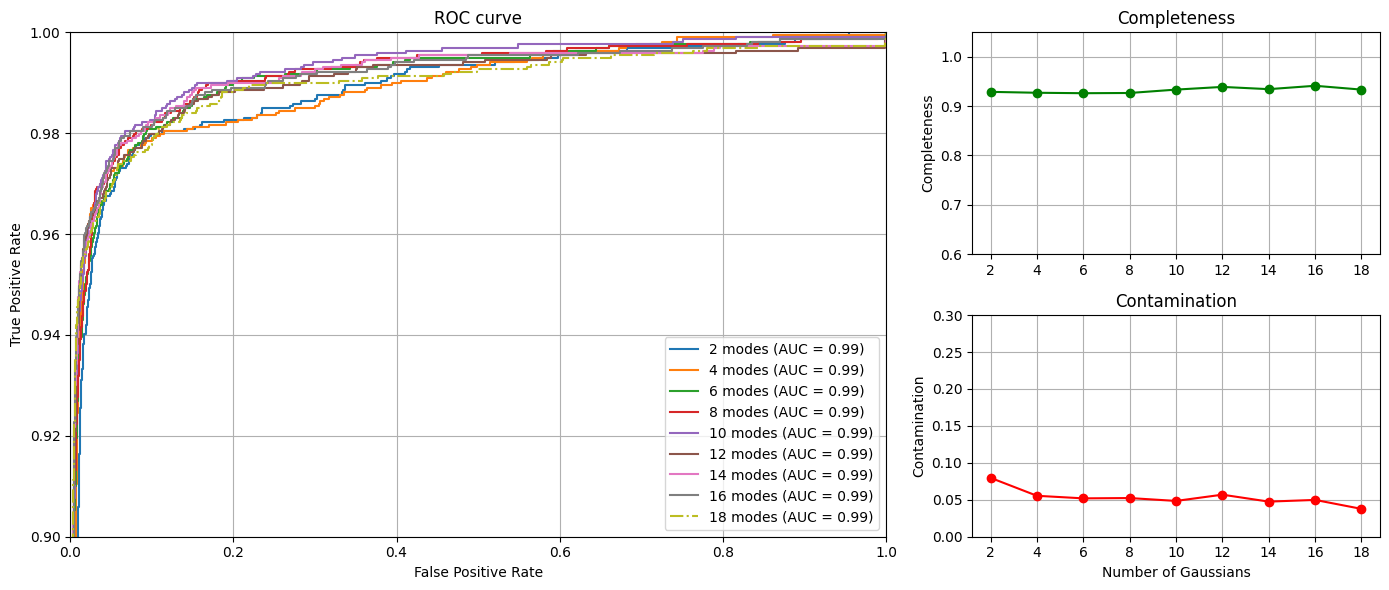

In [24]:

completeness_list = []
contamination_list = []
roc_curves = []
for k in K_range:
    #fitting the data with an increasing number of modes
    gmm = GMMBayes(n_components = k)
    gmm.fit(xtrain[:,0:4],ytrain)
    #predict the probability that the test set considered, given the values of the magnitudes, is a quasar
    y_prob = gmm.predict_proba(xtest[:,0:4])[:,1]
    #compute the false positive rate, true positive rate and the threshold
    fpr, tpr, thresh = roc_curve(ytest, y_prob)  
    y_pred = gmm.predict(xtest[:,0:4])
    
    roc_auc = auc(fpr, tpr)
    comp, cont = completeness_contamination(y_pred, ytest)
    
    completeness_list.append(comp)
    contamination_list.append(cont)
    roc_curves.append((fpr, tpr, roc_auc, k)) 



# Plot
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(2, 2, width_ratios=[2, 1])

# ROC plot
ax0 = fig.add_subplot(gs[:, 0])
for fpr, tpr, auc_val, k in roc_curves:
    if k == K_best:
        ax0.plot(fpr, tpr, label=f'{k} modes (AUC = {auc_val:.2f})', linestyle = '-.')
    else:
        ax0.plot(fpr, tpr, label=f'{k} modes (AUC = {auc_val:.2f})')
ax0.set_xlim([0, 1])
ax0.set_ylim([0.9, 1])
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.set_title('ROC curve')
ax0.grid(True)
ax0.legend()

# Completeness plot
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(K_range, completeness_list, 'o-g')
ax1.set_title('Completeness')
ax1.set_ylim(0.6, 1.05)
ax1.set_ylabel('Completeness')
ax1.grid(True)

# Contamination plot
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(K_range, contamination_list, 'o-r')
ax2.set_title('Contamination')
ax2.set_ylim(0, 0.3)
ax2.set_xlabel('Number of Gaussians')
ax2.set_ylabel('Contamination')
ax2.grid(True)

plt.tight_layout()
plt.show()


## K-Nearest Neighbors classifier

In K Nearest Neighbors, the probability that a given point belongs to a specific class depends on the class labels of its K nearest neighbors. Specifically, the point is assigned to the class that is most frequent among those neighbors.

In [21]:
scores = []
kneig = np.arange(1,15)
for k in kneig:
    #cross validation
    clf = KNeighborsClassifier(n_neighbors=k)
    CVpredk = cross_val_predict(clf, x, y)
    scores.append(accuracy_score(y, CVpredk)) 

max score is for k=9
Accuracy: 0.98576


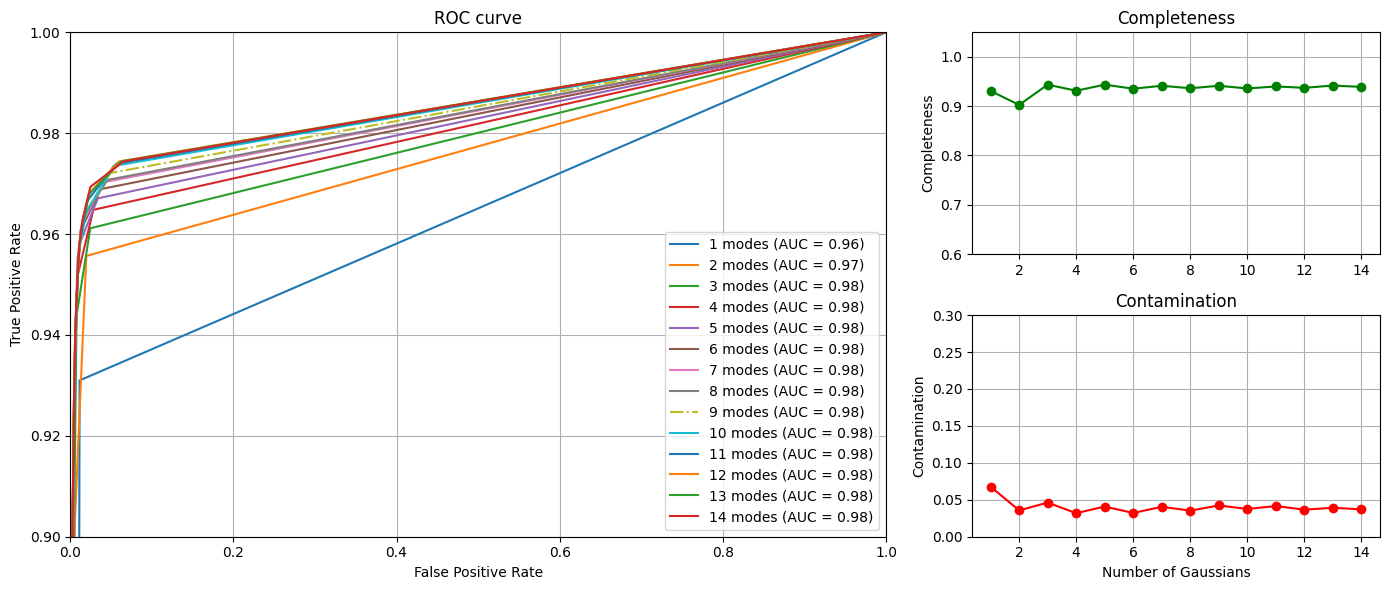

In [22]:
print("max score is for k={:d}".format(kneig[np.argmax(scores)]))
print("Accuracy:", np.max(scores))
K_neig_best = kneig[np.argmax(scores)]
completeness_list = []
contamination_list = []
roc_curves = []
for k in kneig:
    #fitting the data with an increasing number of modes
    knb = KNeighborsClassifier(n_neighbors = k)
    knb.fit(xtrain[:,0:4],ytrain)
    #predict the probability that the test set considered, given the values of the magnitudes, is a quasar
    y_prob = knb.predict_proba(xtest[:,0:4])[:,1]
    #compute the false positive rate, true positive rate and the threshold
    fpr, tpr, thresh = roc_curve(ytest, y_prob)  
    y_pred = knb.predict(xtest[:,0:4])
    
    roc_auc = auc(fpr, tpr)
    comp, cont = completeness_contamination(y_pred, ytest)
    
    completeness_list.append(comp)
    contamination_list.append(cont)
    roc_curves.append((fpr, tpr, roc_auc, k)) 



# Plot
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(2, 2, width_ratios=[2, 1])

# ROC plot
ax0 = fig.add_subplot(gs[:, 0])
for fpr, tpr, auc_val, k in roc_curves:
    if k == kneig[np.argmax(scores)]:
        ax0.plot(fpr, tpr, label=f'{k} modes (AUC = {auc_val:.2f})', linestyle = '-.')
    else:
        ax0.plot(fpr, tpr, label=f'{k} modes (AUC = {auc_val:.2f})')
ax0.set_xlim([0, 1])
ax0.set_ylim([0.9, 1])
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.set_title('ROC curve')
ax0.grid(True)
ax0.legend()

# Completeness plot
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(kneig, completeness_list, 'o-g')
ax1.set_title('Completeness')
ax1.set_ylim(0.6, 1.05)
ax1.set_ylabel('Completeness')
ax1.grid(True)

# Contamination plot
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(kneig, contamination_list, 'o-r')
ax2.set_title('Contamination')
ax2.set_ylim(0, 0.3)
ax2.set_xlabel('Number of Gaussians')
ax2.set_ylabel('Contamination')
ax2.grid(True)

plt.tight_layout()
plt.show()

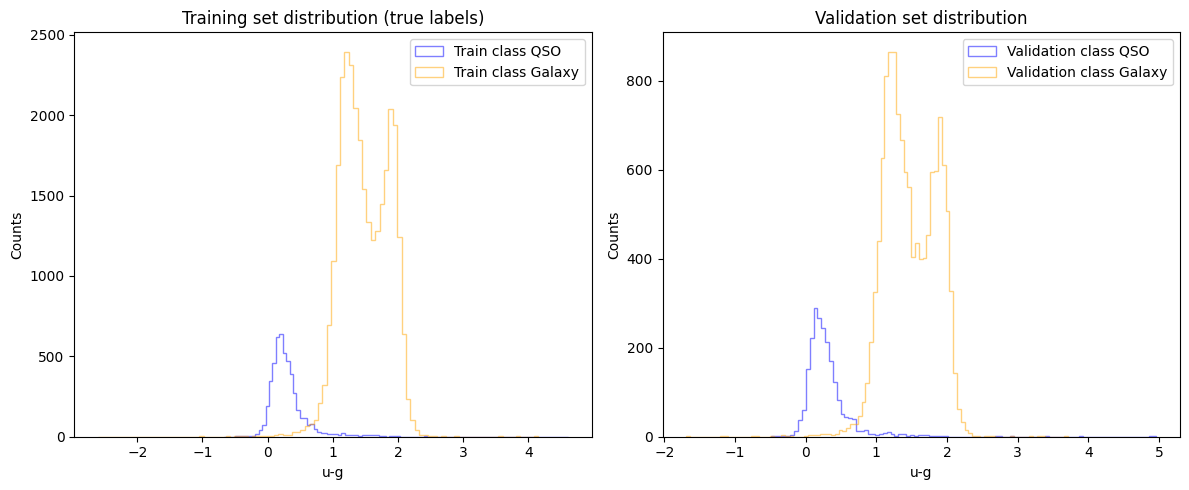

In [20]:
feat_idx = 0

plt.figure(figsize=(12, 5))
#Distribuition of quasars and galaxies in the training set
plt.subplot(1, 2, 1)
plt.hist(xtrain[ytrain == 1][:, feat_idx], bins=100, color='blue', histtype='step',alpha=0.5, label='Train class QSO')
plt.hist(xtrain[ytrain == 0][:, feat_idx], bins=100, color='orange', histtype='step', alpha=0.5, label='Train class Galaxy')
plt.title('Training set distribution (true labels)')
plt.xlabel('u-g')
plt.ylabel('Counts')
plt.legend()

#Distribuition of quasars and galaxies in the validation set
plt.subplot(1, 2, 2)
plt.hist(xtest[ytest == 1][:, feat_idx], bins=100, color='blue',histtype='step', alpha=0.5, label='Validation class QSO')
plt.hist(xtest[ytest == 0][:, feat_idx], bins=100, color='orange',histtype='step',  alpha=0.5, label='Validation class Galaxy')
plt.title('Validation set distribution')
plt.xlabel('u-g')
plt.ylabel('Counts')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import confusion_matrix
#Fitting GMM and K Neighbors with optimal hyperparameters
clf = GMMBayes(n_components= K_best)
clf.fit(xtrain[:,0:4],ytrain)
y_pred_g = clf.predict(xtest[:,0:4]) 

knb = KNeighborsClassifier(n_neighbors = K_neig_best)
knb.fit(xtrain[:,0:4],ytrain)
y_pred_k = knb.predict(xtest[:,0:4])

C = confusion_matrix(ytest, y_pred_g)
print("GMM Confusion matrix\n",C)

C = confusion_matrix(ytest, y_pred_k)
print("KNN Confusion matrix\n",C)

GMM Confusion matrix
 [[12710   102]
 [  128  2060]]
KNN Confusion matrix
 [[12721    91]
 [  128  2060]]


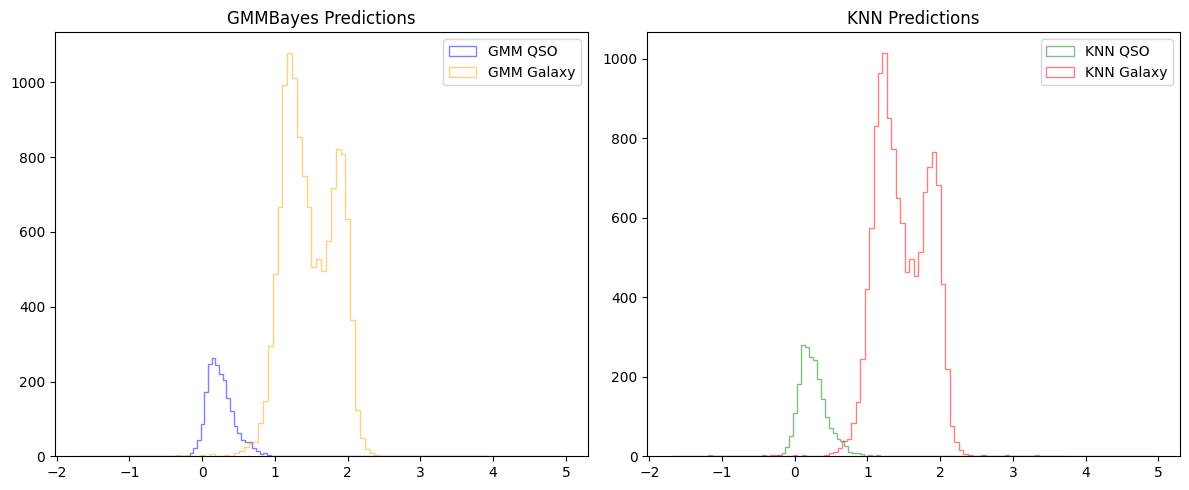

In [17]:
plt.figure(figsize=(12,5))
#Distribuition of predicted quasars and galaxies by GMM Bayes
plt.subplot(1,2,1)
plt.hist(xtest[y_pred_g == 1][:, 0], bins=100, alpha=0.5,histtype='step', label="GMM QSO", color='blue')
plt.hist(xtest[y_pred_g == 0][:, 0], bins=100, alpha=0.5, histtype='step', label="GMM Galaxy", color='orange')
plt.title("GMMBayes Predictions")
plt.legend()

#Distribuition of predicted quasars and galaxies by K Nearest Neighbors
plt.subplot(1,2,2)
plt.hist(xtest[y_pred_k == 1][:, 0], bins= 100, alpha=0.5, histtype='step', label="KNN QSO", color='green')
plt.hist(xtest[y_pred_k == 0][:, 0], bins= 100, alpha=0.5, histtype='step', label="KNN Galaxy", color='red')
plt.title("KNN Predictions")
plt.legend()
plt.tight_layout()
plt.show()

GMM and KNN correctly reproduce the distribuitions of galaxies and quasar, classifying correctly most of the quasars.